<a href="https://colab.research.google.com/github/Terra-01/Veritas-AI-Rain-Prediction-Model-and-Analysis/blob/main/Weather_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VERITAS AI

An immersive Virtual AI program for ambitious high school students, founded and run by Harvard graduate students. For more information, see [Veritas AI](https://www.veritasai.com/).

<p align="center">
    <a href="https://www.veritasai.com/">
        <img src="https://images.squarespace-cdn.com/content/v1/61e9374e0434354049a258f9/f89e8510-6098-4747-a89e-0cd34fe13376/Veritas_Fellowship+MP+White+copy+2.png" width="400" height="400"/>
    </a>
</p>

## Content: All Slides and Codes

The colab links for the code walkthroughs of the first 8 weeks are listed below. **PLEASE DO NOT EDIT THE SCRIPT DIRECTLY. REMEMBER TO SAVE AS A COPY IF YOU WANT TO RUN THE CODE**

Section | Name | Links
--- | --- | ---
1 | **Intro to Basic Python, Numpy, and Pandas** | [Code](https://colab.research.google.com/drive/1z-0Z852bFOUNYhve0wbsCcRJCZpCqcqp?usp=sharing)
2 | **Exploratory Data Analysis** | [Code](https://colab.research.google.com/drive/1VaSC8CsBxAn5JcnN2I5g2YP1m9aWBBMO?usp=sharing)
3 | **Basics in Linear Regression** | [Code](https://colab.research.google.com/drive/1HC4netVsOZT1BHjyUNcu8u8f1Etfoi2b?usp=sharing)
4 | **Basics in Logistic Regression** | [Code](https://colab.research.google.com/drive/1lm5nv5ULZqJBklZJMyRonJGyk0sNjWGi?usp=sharing)
5 | **Intro to Neural Networks** | [Code](https://colab.research.google.com/drive/1OGxD35fQxXdWNDwYGYpZcES5zgo6UvdO?usp=sharing)
6 | **Intro to Convolutional Neural Networks** | [Code](https://colab.research.google.com/drive/1YAjTioD_wUuRIKhacUDpH2TC6HEOfV5u?usp=sharing)
7 | **More in Deep Neural Networks** | [Code](https://colab.research.google.com/drive/1uM7CzWPLifgf16aVtJhWeOGN6A0guvlv?usp=sharing)
8 | **Advanced Convolutional Neural Networks** | [Code](https://colab.research.google.com/drive/1duxfMW5sQbx91c0BJWiP2oSHVdtcbtND?usp=sharing)

REMEMBER: **PLEASE DO NOT EDIT THE SCRIPT DIRECTLY. REMEMBER TO SAVE AS A COPY IF YOU WANT TO RUN THE CODE**


# Australian Rainfall

![main](https://www.ga.gov.au/__data/assets/image/0003/12567/GA14210.jpg)

Australia is a land of extremes with temperatures ranging from highs of 40°C in the central desert regions to below freezing in the higher regions of the country's southeast. Sometimes these extremes can be experienced on a single day.

## Content

This dataset contains about 10 years of daily weather observations from many locations across Australia.

RainTomorrow is the target variable to predict. It means -- did it rain the next day, Yes or No? This column is Yes if the rain for that day was 1mm or more.

## Source & Acknowledgements

Observations were drawn from numerous weather stations. The daily observations are available from [BOM site](http://www.bom.gov.au/climate/data). An example of latest weather observations in Canberra by clicking [here](http://www.bom.gov.au/climate/dwo/IDCJDW2801.latest.shtml). Definitions adapted from [here](http://www.bom.gov.au/climate/dwo/IDCJDW0000.shtml). Data source: [here](http://www.bom.gov.au/climate/dwo/ and http://www.bom.gov.au/climate/data).

Copyright Commonwealth of Australia 2010, Bureau of Meteorology.

## Define Research Question

What question will you try to answer?

Write your project goal in the form of a question to help guide the steps that follow.

## Data Introduction

# **Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Notice that this requires you to download the data form this [link](https://drive.google.com/file/d/1y20KDhvA0v2FOLuAYCMg7TGh9d_xTNV8/view?usp=sharing). Please download the data called *weatherAUS*.

Once you download the *csv* format data set from the link above you can save it in your computer locally at a directory you desire. Please upload that data set onto Colab environment by going to the menu bar on the left and click on the *folder* button to open the directory of the notebook. Please directly upload your dataset to this Colab enrivonment and the path defined below should be working fine.

# **Importing The Required Data**

In [ ]:
from pydrive.auth import GoogleAuth
from google.colab import drive
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

file_id = '1y20KDhvA0v2FOLuAYCMg7TGh9d_xTNV8' #<-- You add in here the id from you google drive file, you can find it


download = drive.CreateFile({'id': file_id})
# Download the file to a local disc
download.GetContentFile('weatherAUS.csv')
data = pd.read_csv("weatherAUS.csv")
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


# **The initial Ratio of Rain Tommorow**

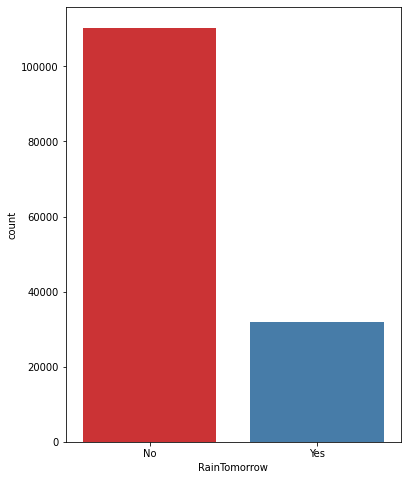

In [ ]:
import seaborn as sns
f, ax = plt.subplots(figsize=(6, 8))
ax = sns.countplot(x="RainTomorrow", data=data, palette="Set1")
plt.show()


# **We Are Cleaning The DataSet**

In [ ]:
categorical = [var for var in data.columns if data[var].dtype=='O']

print('There are {} categorical variables\n'.format(len(categorical)))

print('The categorical variables are :', categorical)


There are 7 categorical variables

The categorical variables are : ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


In [ ]:
numerical = [var for var in data.columns if data[var].dtype!='O']

print('There are {} numerical variables\n'.format(len(numerical)))

print('The numerical variables are :', numerical)


There are 16 numerical variables

The numerical variables are : ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


In [ ]:
data.shape

(145460, 23)

In [ ]:
data.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [ ]:
data.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

## **EDA**


1) Find the shape of your training and testing datasets (Hint: use the shape() function)

In [ ]:
# Your code here
# For checking the shape of the data
data.shape

(145460, 23)

2) Plot a histogram of one of the columns you find interesting in the data frame. (Hint: Recall the *.hist()* method)

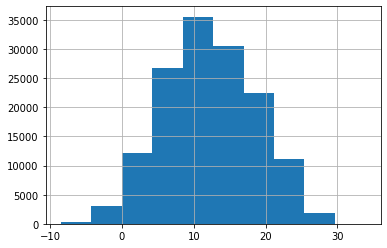

In [ ]:
# Your code here
# When MinTemp is low the chance of rainfall is higher
data["MinTemp"].hist(bins= 10)

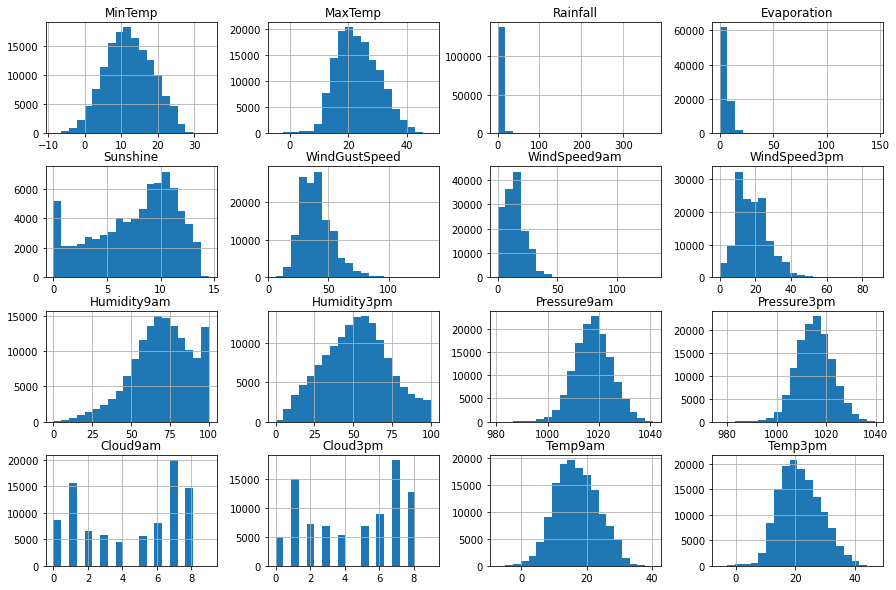

In [ ]:
# Checking all the data
data.hist(bins=20, figsize=(15,10))
plt.show()

3) Plot a scatter plot of two columns that you find interesting in the data fraem. (Hint: Recall in *matplotlib.pyplot* there is the *.scatter* method)

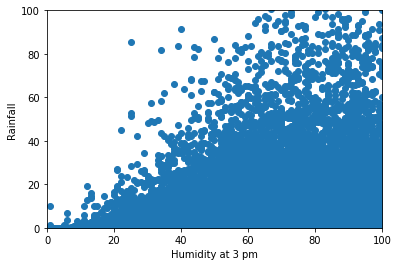

In [ ]:
# The factor likely to affect rainfall is humidity
# Chose 3pm for humidity because it is the closest time to the next day
plt.scatter(data['Humidity3pm'], data['Rainfall'])
plt.xlim( [ 0, 100 ] )
plt.ylim( [ 0, 100 ] )
plt.xlabel('Humidity at 3 pm')
plt.ylabel('Rainfall')
plt.show()

4) Try to think of one more step on your own here. What else would you like to know about the data or how it is arranged?

In [ ]:
# Your code here
# Checking for any duplicate rows in the database
data.duplicated().sum()

0

In [ ]:
# Checking for NULL values in the columns of the database
data.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [ ]:
# Dropping the rows in which Temp9am, Humidity3pm, RainToday,RainTomorrow's
# value is NULL
data.dropna(subset=['Temp9am', 'Humidity3pm', 'RainToday','RainTomorrow']).isnull().sum()

Date                 0
Location             0
MinTemp            161
MaxTemp            123
Rainfall             0
Evaporation      57510
Sunshine         63574
WindGustDir       7350
WindGustSpeed     7321
WindDir9am        8869
WindDir3pm        1810
WindSpeed9am       753
WindSpeed3pm       726
Humidity9am        130
Humidity3pm          0
Pressure9am      12314
Pressure3pm      12251
Cloud9am         51257
Cloud3pm         52665
Temp9am              0
Temp3pm              0
RainToday            0
RainTomorrow         0
dtype: int64

In [ ]:
# Here we can see that removing all of the NULL values from certain columns
# Results in clearing of NULL values for other columns as well
# Now, we can proceed with the data as it is clean

In [ ]:
# Checking for the count of yes or no in the RainToday column
data["RainToday"].value_counts()

No     110319
Yes     31880
Name: RainToday, dtype: int64

# Baseline Model

Fundamentally, a baseline is a model that is both simple to set up and has a reasonable chance of providing decent results.

# To do:

1) Select which variables you will use in your model (start with 2 or 3)

2) Separate training and testing sets

3) Create a linear regression model. Code examples are [here](https://colab.research.google.com/drive/1HC4netVsOZT1BHjyUNcu8u8f1Etfoi2b?authuser=1) for reference.


## Challenge:
- Create another model with different variables to see if you can get higher test accuracy
- Write 3 sentences about why you chose those variables



In [ ]:
# Checking the initial dataset
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
# Putting clean data in data2
data2 = data.dropna(subset=['Temp9am', 'Humidity3pm', 'RainToday', 'RainTomorrow'])

# **Linear model with 3 variables**

In [ ]:
from sklearn.model_selection import train_test_split
X = data2[['Temp9am', 'Humidity3pm', 'RainToday']]
y = data2['RainTomorrow']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)


In [ ]:
!pip install category-encoders


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import category_encoders as ce

encoder = ce.BinaryEncoder(cols=['RainToday'])

X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test)


In [ ]:
X_train.head()

,Temp9am,Humidity3pm,RainToday_0,RainToday_1
43506,15.6,80.0,0,1
98345,18.3,40.0,1,0
74810,29.2,16.0,1,0
91324,26.5,53.0,1,0
5601,19.9,68.0,1,0


### **Model 1 -> We built a model with all variables**

In [ ]:
from sklearn.linear_model import LogisticRegression
# instantiate the model
logreg = LogisticRegression(solver='liblinear', random_state=0)
# fit the model
logreg.fit(X_train, y_train)


LogisticRegression(random_state=0, solver='liblinear')

In [ ]:
y_pred_test = logreg.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))


Model accuracy score: 0.8286
              precision    recall  f1-score   support

          No       0.85      0.95      0.90     21294
         Yes       0.70      0.40      0.51      6086

    accuracy                           0.83     27380
   macro avg       0.77      0.67      0.70     27380
weighted avg       0.81      0.83      0.81     27380



**82.8% Accuracy**

# **Linear models with and without balanced data**

In [ ]:
data.dropna(subset=['RainTomorrow'], inplace = True)

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data.drop('Date', axis=1, inplace = True)


In [ ]:
X = data.drop(['RainTomorrow'], axis=1)

y = data['RainTomorrow']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)


In [ ]:
numerical = [col for col in X_train.columns if X_train[col].dtypes != 'O']
categorical = [col for col in X_train.columns if X_train[col].dtypes == 'O']
for df1 in [X_train, X_test]:
    for col in numerical:
        col_median=X_train[col].median()
        df1[col].fillna(col_median, inplace=True)



In [ ]:
X_train[numerical].isnull().sum()


MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
Year             0
Month            0
Day              0
dtype: int64

In [ ]:
import category_encoders as ce

encoder = ce.BinaryEncoder(cols=['RainToday'])

X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test)


## **Model 2 -> We built the model with clean data**

In [ ]:
X_train.columns

Index(['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday_0', 'RainToday_1', 'Year', 'Month', 'Day'],
      dtype='object')

In [ ]:
X_train = pd.concat([X_train[numerical], X_train[['RainToday_0', 'RainToday_1']],
                     pd.get_dummies(X_train['Location']),
                     pd.get_dummies(X_train.WindGustDir),
                     pd.get_dummies(X_train.WindDir9am),
                     pd.get_dummies(X_train.WindDir3pm)], axis=1)


In [ ]:
X_train.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,NNW,NW,S,SE,SSE,SSW,SW,W,WNW,WSW
113462,13.9,22.6,0.2,4.8,8.5,41.0,20.0,28.0,65.0,55.0,...,0,0,1,0,0,0,0,0,0,0
89638,22.4,29.4,2.0,6.0,6.3,33.0,7.0,19.0,71.0,59.0,...,0,0,0,0,0,0,0,0,0,0
138130,9.7,36.2,0.0,11.4,12.3,31.0,15.0,11.0,6.0,2.0,...,0,0,0,0,0,0,0,0,0,0
87898,20.5,30.1,0.0,8.8,11.1,37.0,22.0,19.0,59.0,53.0,...,0,0,0,0,0,0,0,0,0,0
16484,16.8,29.2,0.0,4.8,8.5,39.0,0.0,7.0,72.0,53.0,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
X_test = pd.concat([X_test[numerical], X_test[['RainToday_0', 'RainToday_1']],
                     pd.get_dummies(X_test.Location),
                     pd.get_dummies(X_test.WindGustDir),
                     pd.get_dummies(X_test.WindDir9am),
                     pd.get_dummies(X_test.WindDir3pm)], axis=1)


In [ ]:
X_train.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,NNW,NW,S,SE,SSE,SSW,SW,W,WNW,WSW
count,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,...,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000
mean,12.193497,23.237216,2.320550,5.188010,8.041154,39.884074,13.982524,18.618211,68.867486,51.509547,...,0.054530,0.060288,0.067259,0.075162,0.064059,0.056402,0.064464,0.069334,0.060798,0.065483
std,6.388279,7.094149,8.463867,3.169676,2.769480,13.116959,8.832265,8.703193,18.935587,20.530723,...,0.227061,0.238021,0.250471,0.263654,0.244860,0.230698,0.245578,0.254022,0.238960,0.247378
min,-8.200000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.600000,18.000000,0.000000,4.000000,8.200000,31.000000,7.000000,13.000000,57.000000,37.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16.800000,28.200000,0.600000,5.400000,8.700000,46.000000,19.000000,24.000000,83.000000,65.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,33.900000,48.100000,371.000000,86.200000,14.500000,135.000000,130.000000,83.000000,100.000000,100.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### **Without Balancing the Data**

In [ ]:
###  Scaling

In [ ]:
cols = X_train.columns
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)
X_train = pd.DataFrame(X_train, columns=[cols])
X_test = pd.DataFrame(X_test, columns=[cols])


In [ ]:
# Insert your advanced model code here #
# train a logistic regression model on the training set
from sklearn.linear_model import LogisticRegression


# instantiate the model
logreg = LogisticRegression(solver='liblinear', random_state=0)


# fit the model
logreg.fit(X_train, y_train)

y_pred_test = logreg.predict(X_test)



/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  FutureWarning,


In [ ]:
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))

Model accuracy score: 0.8500
              precision    recall  f1-score   support

          No       0.87      0.95      0.91     22067
         Yes       0.74      0.52      0.61      6372

    accuracy                           0.85     28439
   macro avg       0.80      0.73      0.76     28439
weighted avg       0.84      0.85      0.84     28439



**85% Accuracy**

### **With Balanced Data**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0, stratify=y)


In [ ]:
y_train.value_counts()

No     88252
Yes    25502
Name: RainTomorrow, dtype: int64

### **Undersampling**

In [ ]:
y_encoded = pd.Series(np.where(data["RainTomorrow"].values == 'Yes', 1, 0),
          data.index)
y_encoded

0         0
1         0
2         0
3         0
4         0
         ..
145454    0
145455    0
145456    0
145457    0
145458    0
Length: 142193, dtype: int64

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

undersample = RandomUnderSampler()
X_resampled, y_resampled = undersample.fit_resample(X, y_encoded)



In [ ]:
y_resampled.value_counts()

0    31877
1    31877
dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.2, random_state = 0)

In [ ]:
numerical = [col for col in X_train.columns if X_train[col].dtypes != 'O']
categorical = [col for col in X_train.columns if X_train[col].dtypes == 'O']
for df1 in [X_train, X_test]:
    for col in numerical:
        col_median=X_train[col].median()
        df1[col].fillna(col_median, inplace=True)

import category_encoders as ce

encoder = ce.BinaryEncoder(cols=['RainToday'])

X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test)

X_train = pd.concat([X_train[numerical], X_train[['RainToday_0', 'RainToday_1']],
                     pd.get_dummies(X_train['Location']),
                     pd.get_dummies(X_train.WindGustDir),
                     pd.get_dummies(X_train.WindDir9am),
                     pd.get_dummies(X_train.WindDir3pm)], axis=1)

X_test = pd.concat([X_test[numerical], X_test[['RainToday_0', 'RainToday_1']],
                     pd.get_dummies(X_test.Location),
                     pd.get_dummies(X_test.WindGustDir),
                     pd.get_dummies(X_test.WindDir9am),
                     pd.get_dummies(X_test.WindDir3pm)], axis=1)

cols = X_train.columns
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)
X_train = pd.DataFrame(X_train, columns=[cols])
X_test = pd.DataFrame(X_test, columns=[cols])

In [ ]:
from sklearn.linear_model import LogisticRegression


# instantiate the model
logreg = LogisticRegression(solver='liblinear', random_state=0)


# fit the model
logreg.fit(X_train, y_train)

y_pred_test = logreg.predict(X_test)

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  FutureWarning,


Model accuracy score: 0.7872
              precision    recall  f1-score   support

          No       0.77      0.80      0.79      6241
         Yes       0.80      0.78      0.79      6510

    accuracy                           0.79     12751
   macro avg       0.79      0.79      0.79     12751
weighted avg       0.79      0.79      0.79     12751



**78.9% Accuracy**

**Note ->** We can observe a lower overall accuracy but we can see that the precision of "Yes" has improved.

So this is a more reliable result.

### **Oversampling**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

oversample = RandomOverSampler()
X_resampled, y_resampled = oversample.fit_resample(X, y)


In [ ]:
y_resampled.value_counts()

No     110316
Yes    110316
Name: RainTomorrow, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.2, random_state = 0)

In [ ]:
numerical = [col for col in X_train.columns if X_train[col].dtypes != 'O']
categorical = [col for col in X_train.columns if X_train[col].dtypes == 'O']
for df1 in [X_train, X_test]:
    for col in numerical:
        col_median=X_train[col].median()
        df1[col].fillna(col_median, inplace=True)

import category_encoders as ce

encoder = ce.BinaryEncoder(cols=['RainToday'])

X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test)

X_train = pd.concat([X_train[numerical], X_train[['RainToday_0', 'RainToday_1']],
                     pd.get_dummies(X_train['Location']),
                     pd.get_dummies(X_train.WindGustDir),
                     pd.get_dummies(X_train.WindDir9am),
                     pd.get_dummies(X_train.WindDir3pm)], axis=1)

X_test = pd.concat([X_test[numerical], X_test[['RainToday_0', 'RainToday_1']],
                     pd.get_dummies(X_test.Location),
                     pd.get_dummies(X_test.WindGustDir),
                     pd.get_dummies(X_test.WindDir9am),
                     pd.get_dummies(X_test.WindDir3pm)], axis=1)

cols = X_train.columns
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)
X_train = pd.DataFrame(X_train, columns=[cols])
X_test = pd.DataFrame(X_test, columns=[cols])

In [ ]:
from sklearn.linear_model import LogisticRegression


# instantiate the model
logreg = LogisticRegression(solver='liblinear', random_state=0)


# fit the model
logreg.fit(X_train, y_train)

y_pred_test = logreg.predict(X_test)

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  FutureWarning,


Model accuracy score: 0.7914
              precision    recall  f1-score   support

          No       0.78      0.80      0.79     21952
         Yes       0.80      0.78      0.79     22175

    accuracy                           0.79     44127
   macro avg       0.79      0.79      0.79     44127
weighted avg       0.79      0.79      0.79     44127



**79.1% Accuracy**

Note -> We can observe similar accuracy with similar precision to that of Undersampled one.

# **Improved Model**

For improved models, you can explore more advanced models such as neural network or even recurrent neural network.

# **ANN with and without balanced data**

In [ ]:
X_train.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,NNW,NW,S,SE,SSE,SSW,SW,W,WNW,WSW
0,0.620525,0.490421,0.070620,0.058824,0.482517,0.281250,0.200000,0.076923,0.979592,0.95,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.465394,0.444444,0.012938,0.040107,0.013986,0.179688,0.100000,0.115385,0.857143,0.87,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.093079,0.157088,0.000000,0.058824,0.482517,0.078125,0.000000,0.076923,0.989796,0.86,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.341289,0.419540,0.000270,0.058824,0.482517,0.265625,0.015385,0.000000,0.897959,0.61,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.637232,0.647510,0.000000,0.106952,0.748252,0.265625,0.084615,0.358974,0.653061,0.62,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
y_train

35627    1
58951    1
25063    0
15990    0
7108     0
        ..
45891    1
52416    1
42613    1
43567    1
2732     0
Length: 51003, dtype: int64

In [ ]:
# Code for the ANN based model
import tensorflow as tf
model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(30, activation='relu'), # hidden layer
  tf.keras.layers.Dense(2, activation='softmax') # output layer
])

model.compile(
    optimizer = 'adam', # for this course, we always use adam
    loss = 'sparse_categorical_crossentropy', # since this is classification, we use categorical crossentropy (rather than MSE)
    metrics=['accuracy']) # we'll evaluate based on the accuracy of our predictions

In [ ]:
history = model.fit(X_train, y_train, epochs = 10)

Epoch 1/10
1594/1594 [==============================] - 7s 4ms/step - loss: 0.4066 - accuracy: 0.8113
Epoch 2/10
1594/1594 [==============================] - 6s 4ms/step - loss: 0.4042 - accuracy: 0.8119
Epoch 3/10
1594/1594 [==============================] - 6s 4ms/step - loss: 0.4018 - accuracy: 0.8142
Epoch 4/10
1594/1594 [==============================] - 7s 4ms/step - loss: 0.4004 - accuracy: 0.8128
Epoch 5/10
1594/1594 [==============================] - 6s 4ms/step - loss: 0.3992 - accuracy: 0.8141
Epoch 6/10
1594/1594 [==============================] - 6s 4ms/step - loss: 0.3967 - accuracy: 0.8166
Epoch 7/10
1594/1594 [==============================] - 6s 4ms/step - loss: 0.3962 - accuracy: 0.8162
Epoch 8/10
1594/1594 [==============================] - 6s 4ms/step - loss: 0.3948 - accuracy: 0.8180
Epoch 9/10
1594/1594 [==============================] - 4s 2ms/step - loss: 0.3940 - accuracy: 0.8177
Epoch 10/10
1594/1594 [==============================] - 4s 2ms/step - loss: 0.392

In [ ]:
predictions = model.predict(X_test) # gives us predicted probabilities for each digit
predictions = np.argmax(predictions, axis = 1) # makes predicted digit the classification with highest probability

# Find accuracy on test set
print('Test accuracy: ', np.mean(y_test == predictions))

Test accuracy:  0.7957807230805427


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.77      0.84      0.80      6241
           1       0.83      0.75      0.79      6510

    accuracy                           0.80     12751
   macro avg       0.80      0.80      0.80     12751
weighted avg       0.80      0.80      0.80     12751



KeyError: ignored

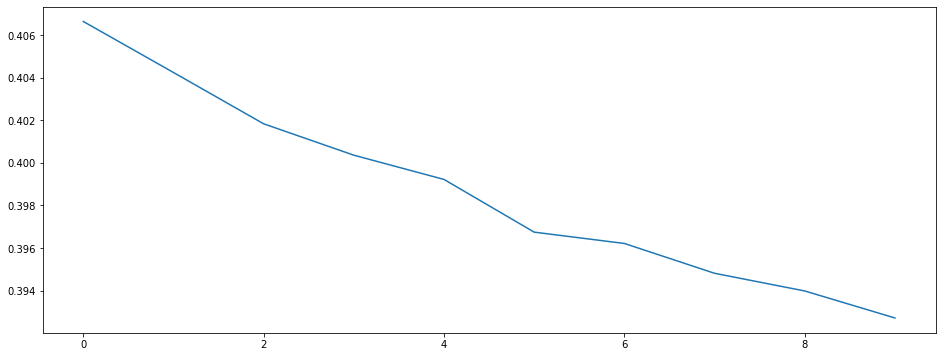

In [ ]:
# define plot_graphs function
# do not edit
def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel("MSE")
  plt.legend(["Train MSE", "Test MSE"])

plt.figure(figsize=(16, 6))
plot_graphs(history, 'loss')


## Tuning

Tuning is the process of maximizing a model's performance without overfitting or creating too high of a variance. In machine learning, this is accomplished by selecting appropriate “hyperparameters.” Hyperparameters can be thought of as the “dials” or “knobs” of a machine learning model.

In [ ]:
# Insert your model tuning code here #
import tensorflow as tf
model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(128, activation='relu'), # hidden layer
  tf.keras.layers.Dense(64, activation='relu'), # hidden layer
  tf.keras.layers.Dense(32, activation='relu'), # hidden layer
  tf.keras.layers.Dense(16, activation='relu'), # hidden layer
  tf.keras.layers.Dense(2, activation='softmax') # output layer
])

model.compile(
    optimizer = 'adam', # for this course, we always use adam
    loss = 'sparse_categorical_crossentropy', # since this is classification, we use categorical crossentropy (rather than MSE)
    metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs = 10)

Epoch 1/10
1594/1594 [==============================] - 4s 2ms/step - loss: 0.4820 - accuracy: 0.7666
Epoch 2/10
1594/1594 [==============================] - 8s 5ms/step - loss: 0.4406 - accuracy: 0.7908
Epoch 3/10
1594/1594 [==============================] - 9s 6ms/step - loss: 0.4242 - accuracy: 0.8009
Epoch 4/10
1594/1594 [==============================] - 6s 4ms/step - loss: 0.4140 - accuracy: 0.8047
Epoch 5/10
1594/1594 [==============================] - 6s 4ms/step - loss: 0.4047 - accuracy: 0.8111
Epoch 6/10
1594/1594 [==============================] - 6s 4ms/step - loss: 0.3972 - accuracy: 0.8134
Epoch 7/10
1594/1594 [==============================] - 6s 4ms/step - loss: 0.3889 - accuracy: 0.8189
Epoch 8/10
1594/1594 [==============================] - 5s 3ms/step - loss: 0.3805 - accuracy: 0.8211
Epoch 9/10
1594/1594 [==============================] - 6s 4ms/step - loss: 0.3732 - accuracy: 0.8260
Epoch 10/10
1594/1594 [==============================] - 6s 4ms/step - loss: 0.363

In [ ]:
predictions = model.predict(X_test) # gives us predicted probabilities for each digit
predictions = np.argmax(predictions, axis = 1) # makes predicted digit the classification with highest probability

# Find accuracy on test set
print('Test accuracy: ', np.mean(y_test == predictions))

Test accuracy:  0.7922515881107364


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.78      0.80      0.79      6241
           1       0.80      0.78      0.79      6510

    accuracy                           0.79     12751
   macro avg       0.79      0.79      0.79     12751
weighted avg       0.79      0.79      0.79     12751



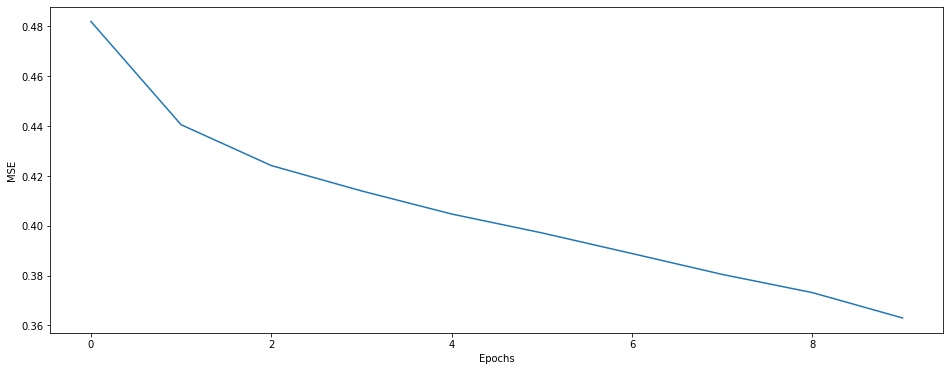

In [ ]:
# define plot_graphs function
# do not edit
def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.xlabel("Epochs")
  plt.ylabel("MSE")

plt.figure(figsize=(16, 6))
plot_graphs(history, 'loss')

In [ ]:
history = model.fit(X_train, y_train, epochs = 100, validation_data=(X_test, y_test))

Epoch 1/100
1594/1594 [==============================] - 8s 5ms/step - loss: 0.2150 - accuracy: 0.9118 - val_loss: 1.0282 - val_accuracy: 0.7328
Epoch 2/100
1594/1594 [==============================] - 7s 5ms/step - loss: 0.1582 - accuracy: 0.9338 - val_loss: 1.1502 - val_accuracy: 0.7546
Epoch 3/100
1594/1594 [==============================] - 5s 3ms/step - loss: 0.1550 - accuracy: 0.9358 - val_loss: 1.1025 - val_accuracy: 0.7393
Epoch 4/100
1594/1594 [==============================] - 4s 3ms/step - loss: 0.1487 - accuracy: 0.9380 - val_loss: 1.1277 - val_accuracy: 0.7451
Epoch 5/100
1594/1594 [==============================] - 4s 3ms/step - loss: 0.1463 - accuracy: 0.9408 - val_loss: 1.1141 - val_accuracy: 0.7462
Epoch 6/100
1594/1594 [==============================] - 4s 3ms/step - loss: 0.1418 - accuracy: 0.9415 - val_loss: 1.1486 - val_accuracy: 0.7464
Epoch 7/100
1594/1594 [==============================] - 4s 3ms/step - loss: 0.1441 - accuracy: 0.9407 - val_loss: 1.1468 - val_ac

In [ ]:
predictions = model.predict(X_test) # gives us predicted probabilities for each digit
predictions = np.argmax(predictions, axis = 1) # makes predicted digit the classification with highest probability

# Find accuracy on test set
print('Test accuracy: ', np.mean(y_test == predictions))

Test accuracy:  0.7464512587248059


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.73      0.76      0.75      6241
           1       0.76      0.73      0.75      6510

    accuracy                           0.75     12751
   macro avg       0.75      0.75      0.75     12751
weighted avg       0.75      0.75      0.75     12751



In [ ]:
X_train.shape

(51003, 118)

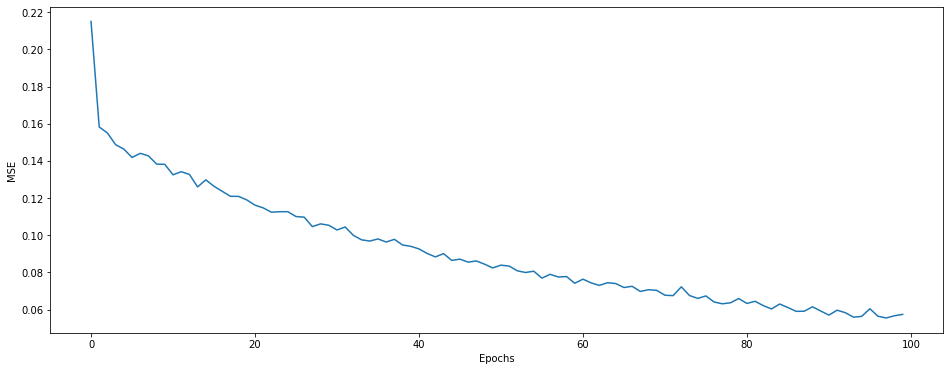

In [ ]:
def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.xlabel("Epochs")
  plt.ylabel("MSE")

plt.figure(figsize=(16, 6))
plot_graphs(history, 'loss')

# Performance Summary

Make a presentation of your result. You can refer to the syntax below.

Markdown | Preview
--- | ---
`**Model 1**` | **Model 2**
`*70%*` or `_italicized text_` | *90%*
`` `Monospace` `` | `Monospace`
`~~strikethrough~~` | ~~strikethrough~~
`[A link](https://www.google.com)` | [A link](https://www.google.com)
`![An image](https://www.google.com/images/rss.png)` | ![An image](https://www.google.com/images/rss.png)

More resources about creating tables in markdown of colab can be found [here](https://colab.research.google.com/notebooks/markdown_guide.ipynb#scrollTo=Lhfnlq1Surtk).

# Conclusion

- Does your model (baseline or advanced) answer the questions you are interested in?
- Does your EDA present the visual aid that you need to create the models?
- How can you improve your models if you have one more week of time before submission?